In [1]:
import os
import sys
sys.path.append(os.path.expanduser('~'))
import numpy as np 
from matplotlib import pyplot as plt
from datetime import datetime as dt
import figures as fgs
from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils
import numba as nb
import time
import importlib
import json
from scipy.optimize import minimize
from scipy.ndimage import binary_closing
from skyfield.api import load, wgs84
import cupy
import helper_discrepancies as hd

importlib.reload(hd)

BDC is using numpy
BDC is using numpy


<module 'helper_discrepancies' from '/home/thomasb/albatros_analysis/scripts/orbcomm/helper_discrepancies.py'>

In [2]:
def plot_all_blines(V, ant_idxs, ant_nums):
    """
    Plot all baselines in a 3-column grid, each with its own colorbar.
    
    V: (Nbl, Nfreq, Ntime)
    ant_idxs: list of antenna indices used to form baselines
    """
    Nbl, Nfreq, Ntime = V.shape
    nants = len(ant_idxs)

    ncols = 3
    nrows = int(np.ceil(Nbl / ncols))

    # Make plots longer by adjusting height
    fig, ax = plt.subplots(nrows, ncols,
                           figsize=(5*ncols, 4*nrows),
                           sharex=True, sharey=True)

    # Ensure ax is always 2D
    ax = np.atleast_2d(ax)

    bline_idx = 0
    for i in range(nants):
        ant1_idx = ant_idxs[i]
        for j in range(i+1, nants):
            ant2_idx = ant_idxs[j]

            # Compute row, col in the grid
            r = bline_idx // ncols
            c = bline_idx % ncols

            im = ax[r, c].imshow(V[bline_idx, :, :],
                                 aspect='auto',
                                 interpolation='nearest')
            fig.colorbar(im, ax=ax[r, c], fraction=0.046, pad=0.04, label='|V|')
            ax[r, c].set_title(f'Ant {ant_nums[ant1_idx]} - Ant {ant_nums[ant2_idx]}')

            bline_idx += 1

    # Hide any unused subplots
    for idx in range(Nbl, nrows*ncols):
        r = idx // ncols
        c = idx % ncols
        ax[r, c].axis('off')

    plt.tight_layout()
    plt.show()

In [3]:
path_config = '/home/thomasb/albatros_analysis/scripts/orbcomm/config/config_batch1.json'
path_cutter = '/scratch/thomasb/batch_1753132820/data/cutting_discrep.json'
path_pulses = '/scratch/thomasb/batch_1753132820/data/pulses.json'

In [4]:
#open config and get metadata
with open(path_config, "r") as f:
    config = json.load(f)
ant_names, ant_coords, dir_parents, spec_offsets = [], [], [], []
# Call get_starting_index for all antennas except reference
for i, (ant, details) in enumerate(config["antennas"].items()):
    dir_parents.append(details["path"])
    spec_offsets.append(details["clock_offset"])
    ant_names.append(details["name"])
    ant_coords.append(details["coordinates"])

ant_numbers = np.array([int(name.split()[1]) for name in ant_names])
batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
chanstart = config["frequency"]["start_channel"]
chanend = config["frequency"]["end_channel"]
osamp = config["correlation"]["osamp"]
pfb_size = config["correlation"]["pfb_size"]
new_acclen = config["correlation"]["new_acclen"]

new_chunk_len = (new_acclen*4096*osamp)/250e6
tle_path = outils.get_tle_file(batch_start_ts, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
print(new_acclen)
print(batch_start_ts)
print(batch_end_ts)

1024
1753132820
1753200010


In [5]:
with open(path_pulses, "r") as f:
    pulses = json.load(f)

In [168]:
idx_pulse = 1

pulse = pulses[idx_pulse]
pulse_start_ts = pulse['t_start']
pulse_end_ts = pulse['t_end']
satID = pulse['sat']
chan_det = pulse['channel']

ant_idxs = [0, 2, 3, 4, 5, 6]
ant_nums = [1, 2, 4, 5, 6, 7, 8]

if chan_det%2 == 0:
    old_chans = np.arange(chan_det-2, chan_det+2)
else:
    old_chans = np.arange(chan_det-1, chan_det+3)

print(old_chans)
old_chans_big = old_chans+1834

chans_new = np.arange(osamp) + old_chans[:, None] * osamp
chans_new = chans_new.ravel()
#print(np.linspace(old_chans_big[0], old_chans_big[-1]+1, osamp*4, endpoint=False)- (chans_new/osamp+1834))
#print(chans_new/osamp)
sat_freqs = 250e6 - ((chans_new/osamp + 1834)/(4096/250e6))
print(satID)


[14 15 16 17]
33591


In [169]:
fname = f'data_raw_osamp={osamp}_start={pulse_start_ts}_end={pulse_end_ts}_chans={old_chans_big[0]}:{old_chans_big[-1]}.npy'
disk_path = f'/scratch/thomasb/batch_{batch_start_ts}/data/{fname}'
print(fname)

data_raw_osamp=64_start=1753134223_end=1753134714_chans=1848:1851.npy


In [170]:
data = np.load(disk_path)

In [171]:
nants, npols, nspec, nchans = data.shape
print('Data shape', data.shape)

Data shape (7, 2, 467968, 256)


In [172]:
V = hd.efield_to_vis(
    data,
    pulse_start_ts,
    pulse_end_ts-1,
    [0, 2, 3, 4, 5, 6],        
    ant_coords,
    satID,
    sat_freqs,
    acclen = new_acclen,
    osamp = osamp,
    bb_spectrum_T = 4096/250e6)

467300
(7, 2, 467300, 256)


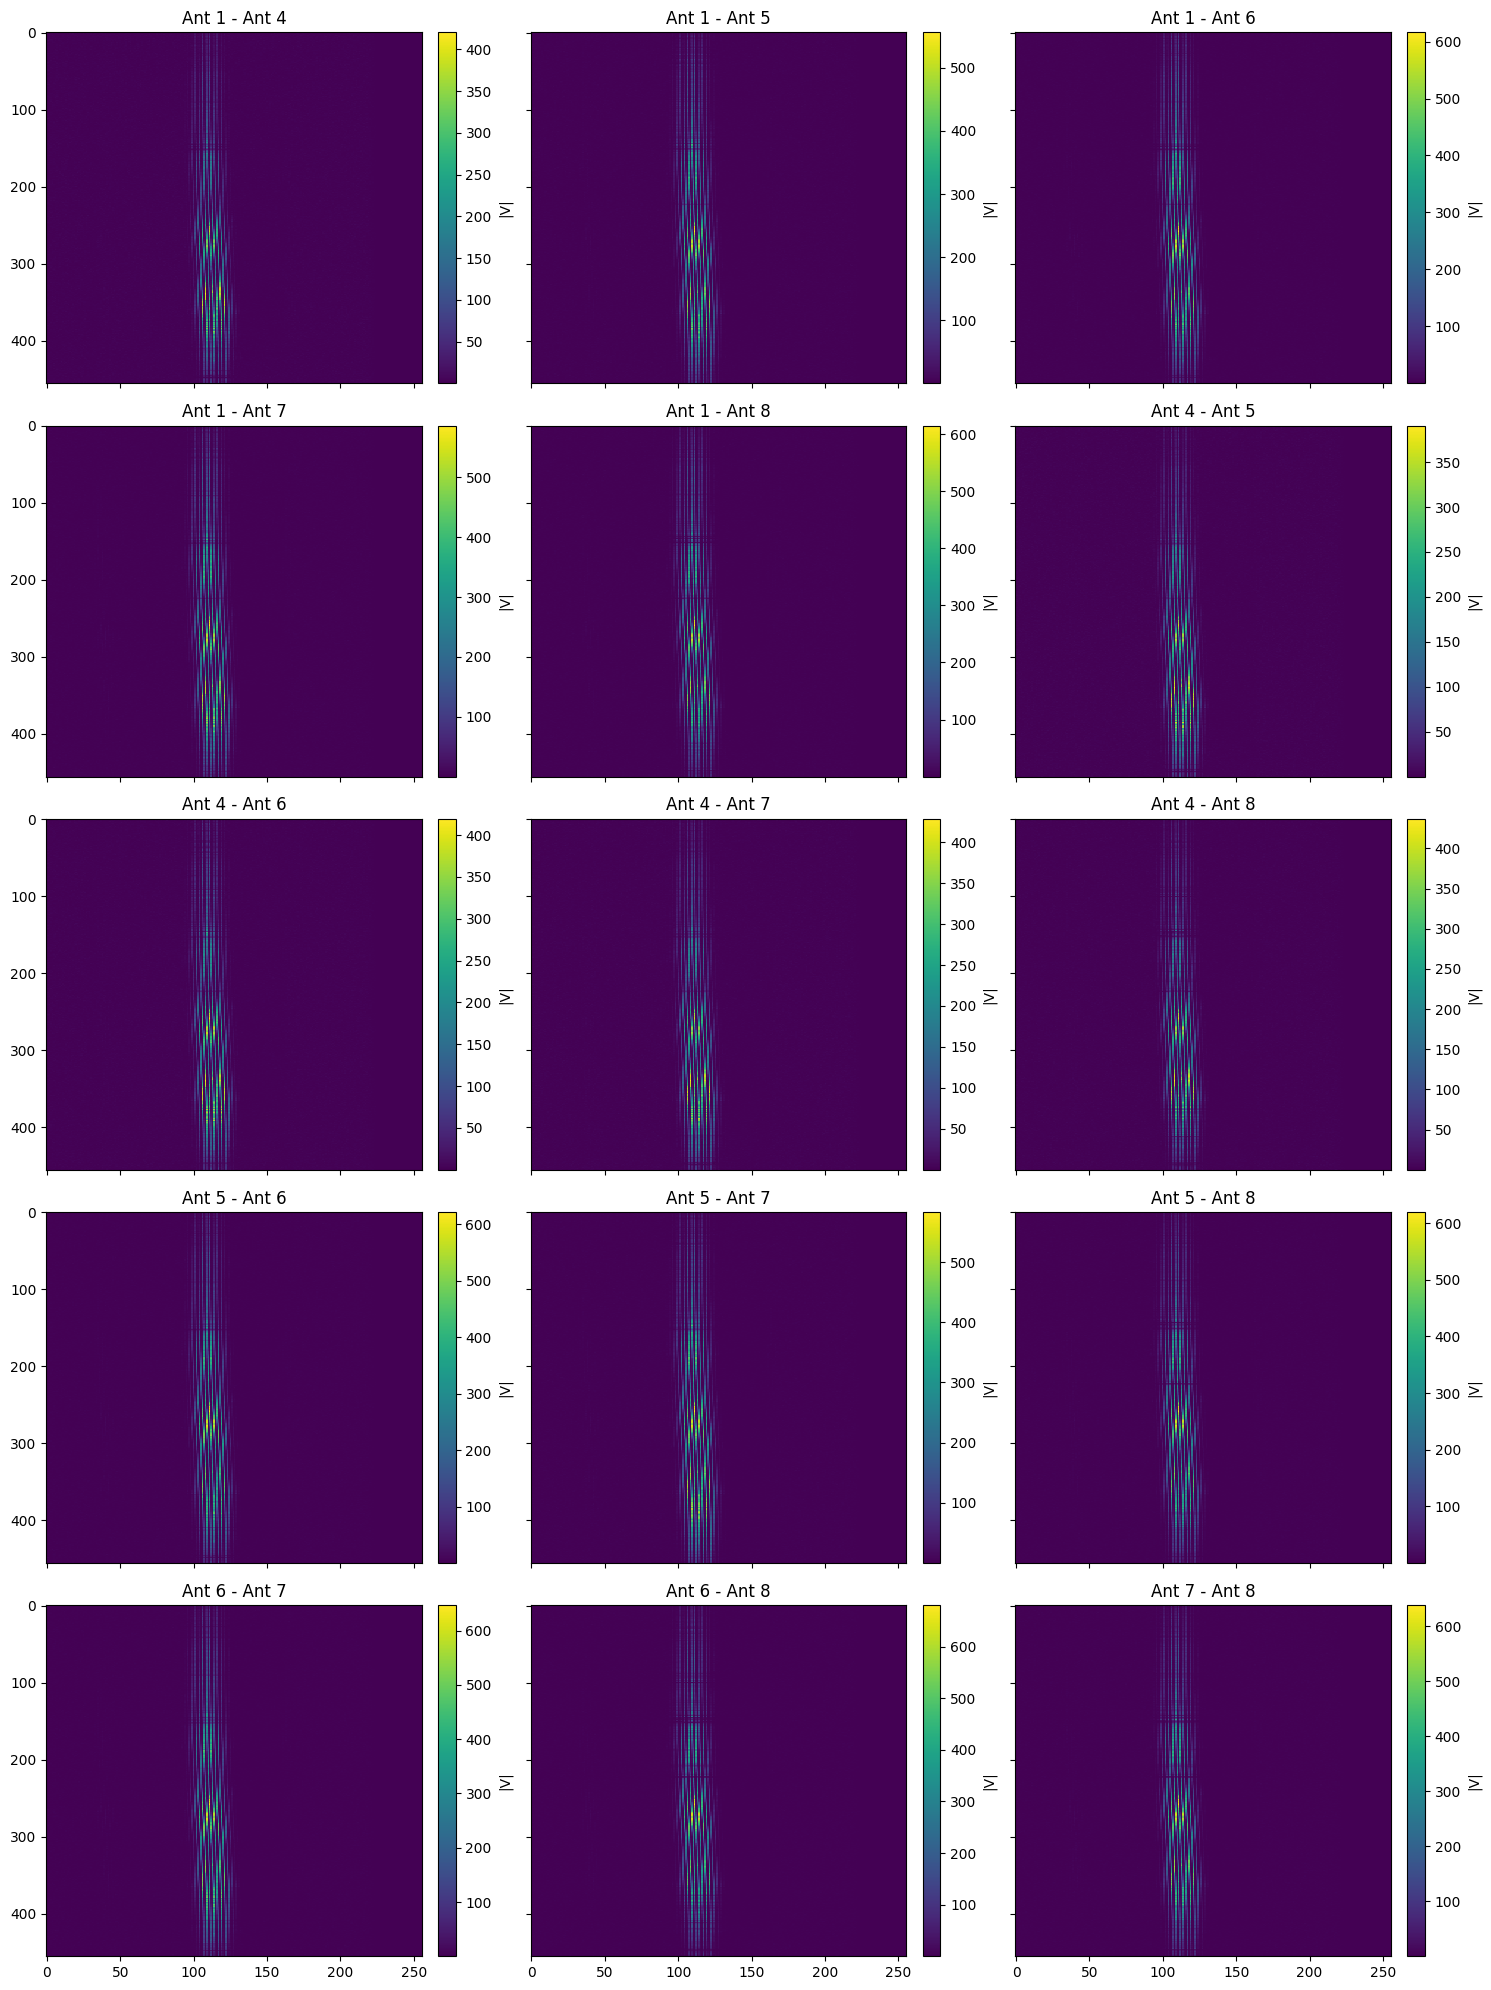

In [173]:
plot_all_blines(V[:, :, :], ant_idxs, ant_nums)

In [174]:
V.shape

(15, 456, 256)

In [175]:
assert satID in {28654,25338,33591,57166,59051}
if satID in {59051, 57166}:
    sat_type = "METEOR"
if satID in {28654,25338,33591}:
    sat_type = "NOAA"

In [176]:
chan_slice = hd.find_signal_channels(V, sat_type)
print(chan_slice)

slice(101, 121, None)


In [177]:
import numpy as np

def amplitude_cut(data, chan_slice, win_size=120):
    '''
    Selects the contiguous window (length = win_size samples) with the highest median SNR.
    '''
    # --- signal power ---
    data_signal = data[:, :, chan_slice]
    power = np.median(np.abs(data_signal)**2, axis=2)

    # --- noise power ---
    off_mask = np.ones(data.shape[-1], dtype=bool)
    off_mask[chan_slice] = False
    off   = data[:, :, off_mask]
    noise = np.median(np.median(np.abs(off)**2, axis=2), axis=1, keepdims=True)

    # --- SNR ---
    snr = power / (noise + 1e-30)

    # collapse pols → robust time series
    snr_all = np.median(snr, axis=0)

    # --- sliding window median ---
    if win_size > len(snr_all):
        return (0, len(snr_all))

    windows = np.lib.stride_tricks.sliding_window_view(snr_all, win_size)
    medians = np.median(windows, axis=1)

    # --- best window ---
    start = int(np.argmax(medians))
    end = start + win_size

    return start, end

In [178]:
start_chunk, end_chunk = amplitude_cut(V, chan_slice)
print(start_chunk)
print(end_chunk)

#start_chunk, end_chunk = 0, 120

247
367


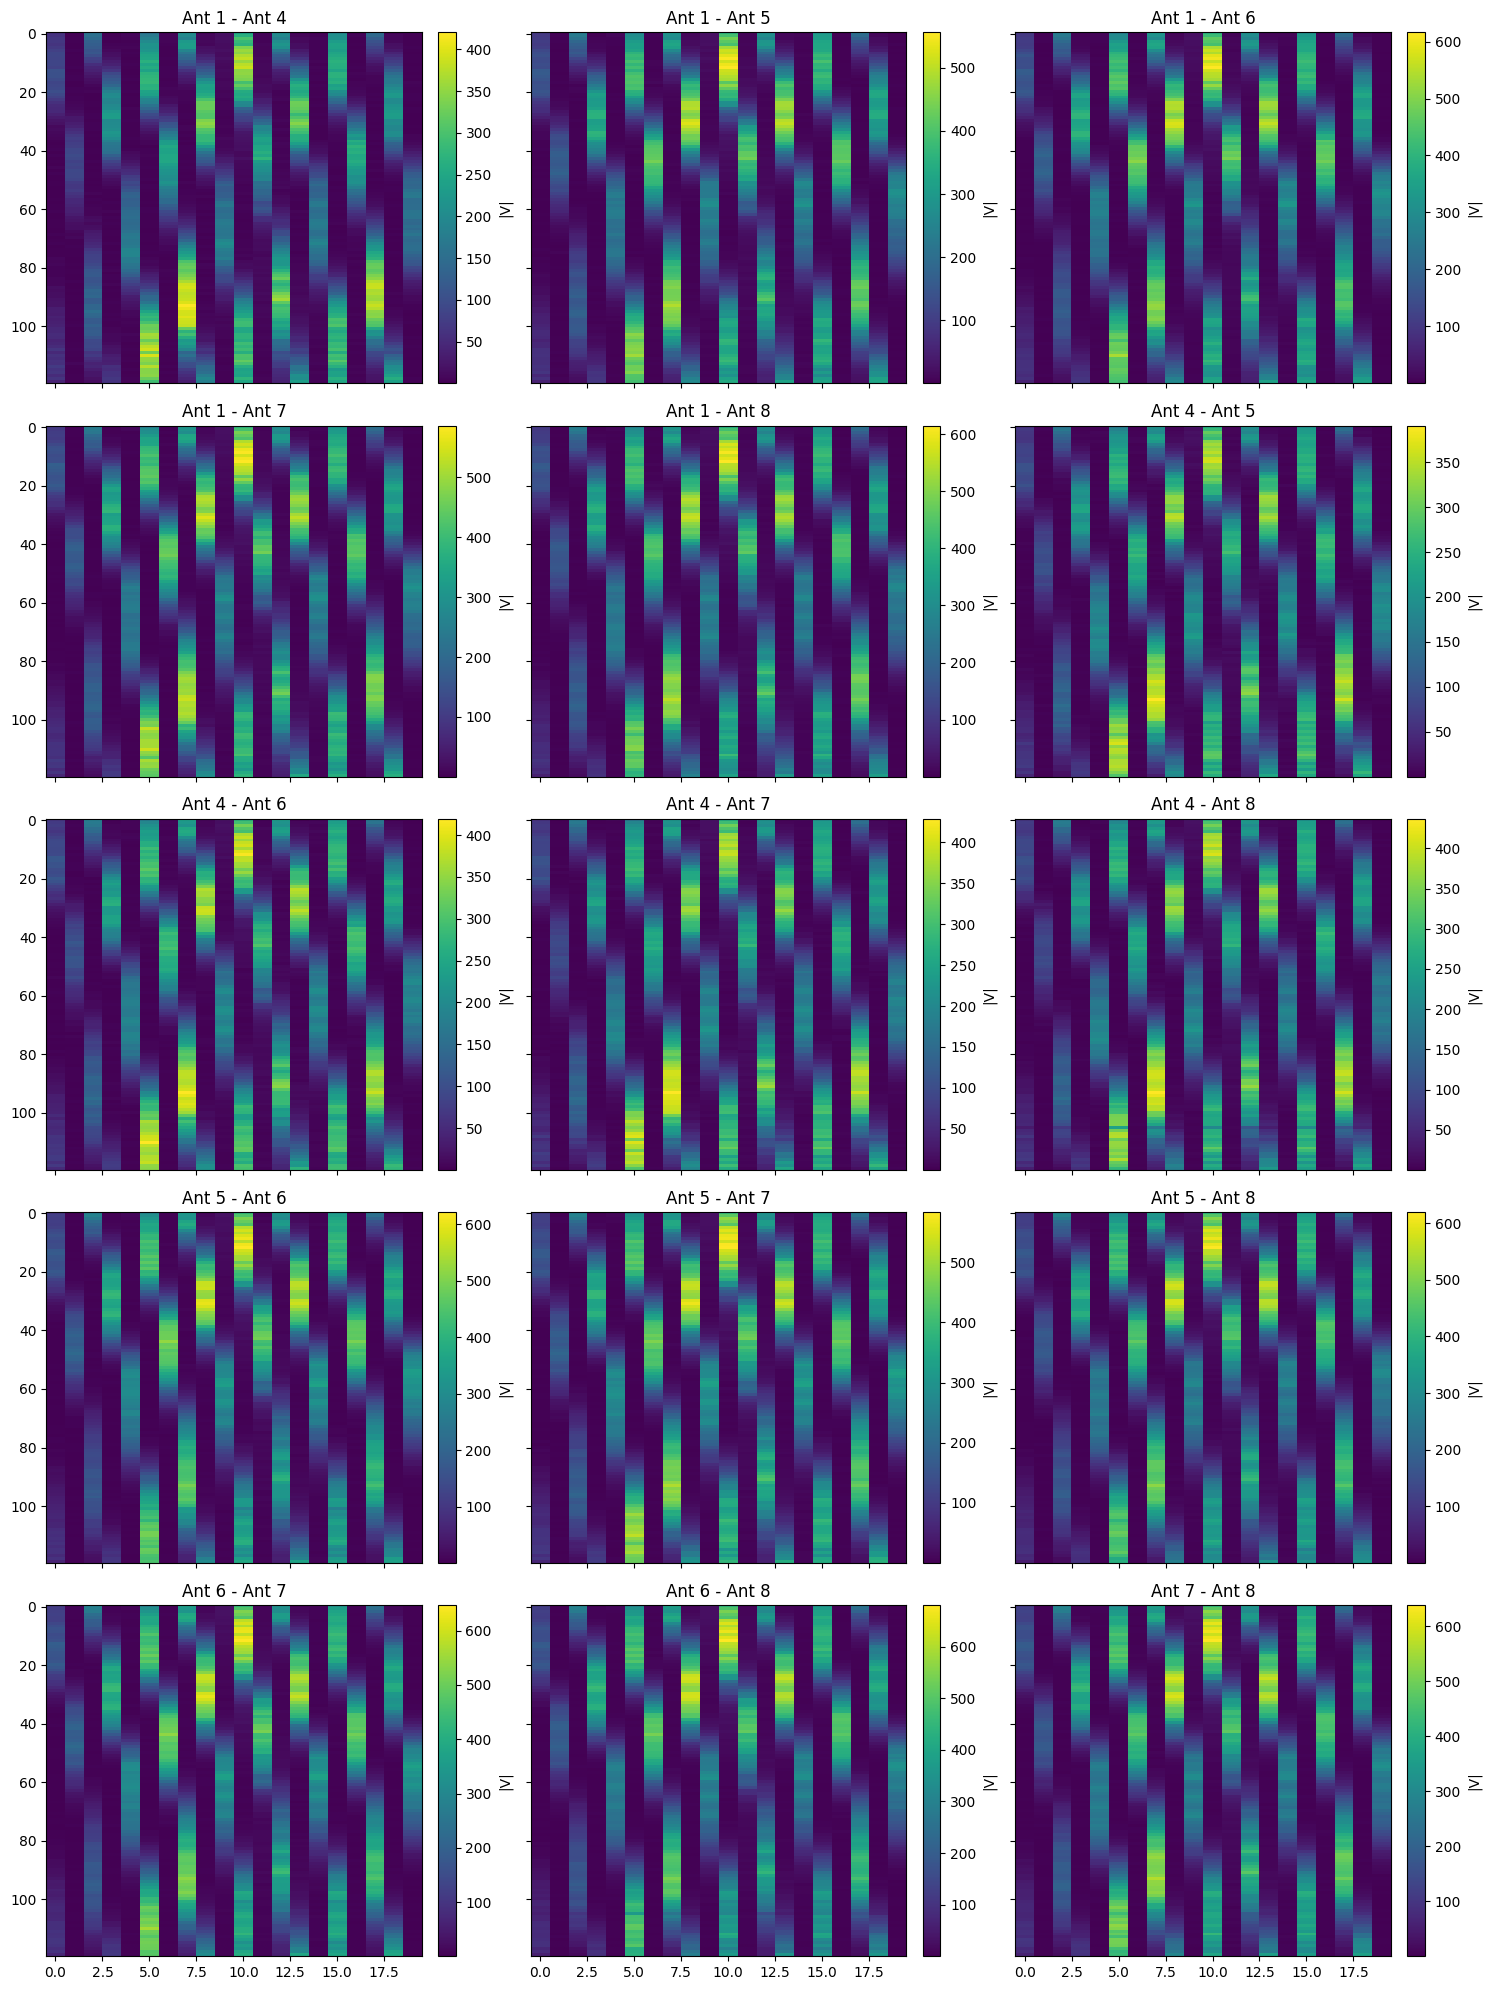

In [179]:
plot_all_blines(V[:, start_chunk:end_chunk, chan_slice], ant_idxs, ant_nums)
#plot_all_blines(V[:, 250:400, 68:88], ant_idxs, ant_nums)

In [180]:
new_chans = [chan_slice.start,chan_slice.stop]

spectra_start = start_chunk*new_acclen
spectra_end = end_chunk*new_acclen
print(new_chans)
print(spectra_start)
print(spectra_end)

[101, 121]
252928
375808


In [181]:
with open(path_cutter, "r") as f:
    cutter = json.load(f)
if fname not in cutter:
    cutter[fname] = {}
cutter[fname]['new_chans'] = new_chans
cutter[fname]['spectra_start'] = spectra_start
cutter[fname]['spectra_end'] = spectra_end

with open(path_cutter, "w") as f2:
    json.dump(cutter, f2, indent=4)